# Introduction

The following activity is a Credit Card Fraud Detection project based on classification. The dataset used is provided by Kaggle, which contains data about credit card transaction made in September 2013 by European cardholders.

The dataset is mostly composed of PCA tranformed variables and hence they do not need to be cleaned further.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report,
                             roc_auc_score, RocCurveDisplay,
                             average_precision_score,PrecisionRecallDisplay)

In [3]:
# Update this path to match your local file location
# Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
df = pd.read_csv('/content/drive/MyDrive/creditcard.csv')

# EDA

In [4]:
display(df.head())
display(df.shape)
display(df.info())
display(df.describe())
df['Class'].value_counts(normalize=True)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


(284807, 31)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

None

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


,proportion
Class,
0,0.998273
1,0.001727


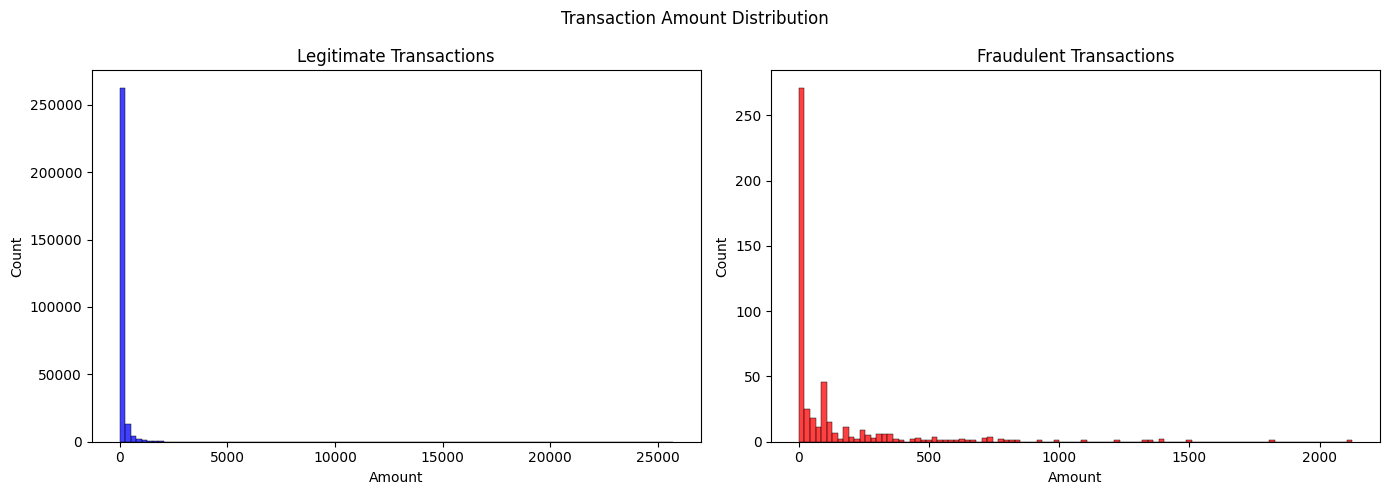

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df[df['Class']==0], x='Amount', bins=100, color='blue', ax=ax1)
ax1.set_title('Legitimate Transactions')
ax1.set_xlabel('Amount')

sns.histplot(data=df[df['Class']==1], x='Amount', bins=100, color='red', ax=ax2)
ax2.set_title('Fraudulent Transactions')
ax2.set_xlabel('Amount')

plt.suptitle('Transaction Amount Distribution')
plt.tight_layout()
plt.show()

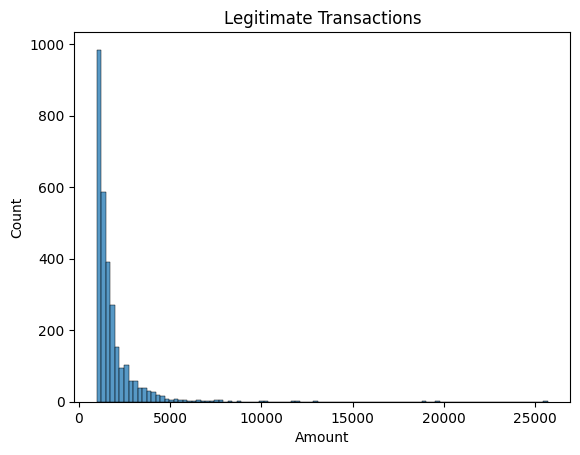

In [6]:
sns.histplot(data=df.query("Class <1 and Amount>1000"), x='Amount', bins=100)
plt.title('Legitimate Transactions')
plt.xlabel('Amount')
plt.show()

Both fraudulent and legitimate transactions are concentrated in the 0–500 range. However, legitimate transactions have a much wider spread, i.e., up to 25,000+, indicating high-value purchases do occur regularly. Fraudulent transactions almost never exceed 1,500 — suggesting fraudsters deliberately keep amounts small, likely to avoid triggering fraud detection thresholds

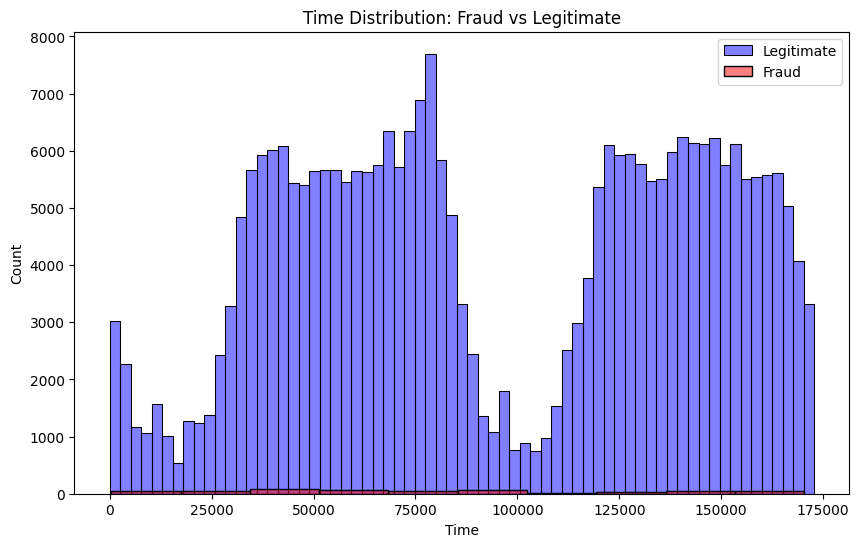

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=df[df['Class']==0], x='Time', label='Legitimate', color='blue', alpha=0.5, ax=ax)
sns.histplot(data=df[df['Class']==1], x='Time', label='Fraud', color='red', alpha=0.5, ax=ax)
ax.set_title('Time Distribution: Fraud vs Legitimate')
ax.legend()
plt.show()

Legitimate Transactions are cyclic -> There are dips around 20,000 and 100,000 probably suggesting less transaction during night time.

On the other hand frauds are distributed linearly over time, meaning fraud transaction happen irrespective of day and night.

In [8]:
display(df.isna().sum())
display(df.duplicated().sum())
df = df.drop_duplicates()
display(df.duplicated().sum())
df.shape

np.int64(1081)

np.int64(0)

(283726, 31)

The dataset is pre-cleaned by Kaggle — no missing values exist in any field.
1081 duplicate rows found and removed. Final dataset: 283,726 transactions.

In [9]:
df["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.998333
1,0.001667


Because only 0.17% of transactions are fraud, a model predicting
"legitimate" for everything achieves 99.83% accuracy while catching
zero fraud cases. We evaluate using Precision, Recall, F1, ROC-AUC,
and AUPRC — and apply SMOTE to the training set to address the imbalance.

# Data Preprocessing

Since the data given by Kaggle is almost clean, we only have to perform scaling

In [10]:
df["Hour"] = (df["Time"]%(3600*24))//3600

y = df["Class"]
X = df.drop(columns=['Time','Class'])
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
y_train.value_counts()

,count
Class,
0,226602
1,378


In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
sm =SMOTE(sampling_strategy='auto',k_neighbors=5,random_state=42)
X_train,y_train = sm.fit_resample(X_train,y_train)
y_train.value_counts()

,count
Class,
0,226602
1,226602


### SMOTE is  only applied to Training Data

SMOTE is used to allow synthetic data of minority dataset to be added to the dataset to make sure that there is now a balance between both the classes.
In current example we  use is it to make sure that the model does not classify every sample as Legitimate (That alone would achieve 99.83% accuracy)

Applying SMOTE to Testing dataset would introduce samples that may not reflect reality and give overly optimistic results

In [15]:
pd.DataFrame(X_train).duplicated().sum()

np.int64(1950)

SMOTE introduced a few samples that were duplicated but as they are not original samples we can ignore them

# Model Training & Evaluation

## 1. Naive Bayes (Gaussian)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.05      0.81      0.10        95

    accuracy                           0.98     56746
   macro avg       0.53      0.89      0.54     56746
weighted avg       1.00      0.98      0.99     56746



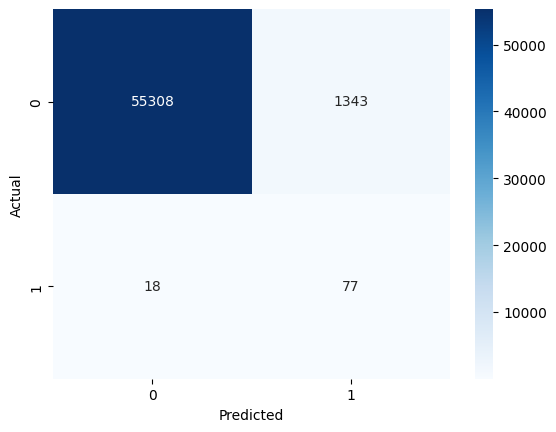

ROC-AUC score for Gaussian NB : 0.9411766782581066
PR-AUC score for Gaussian NB : 0.08035661937530841


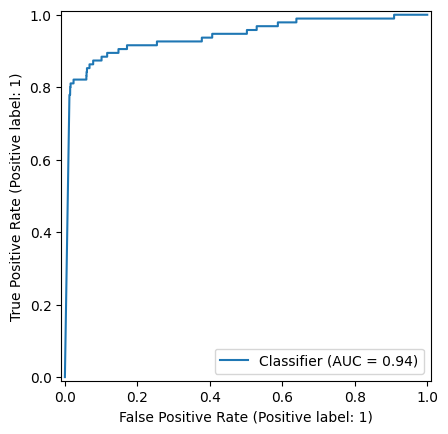

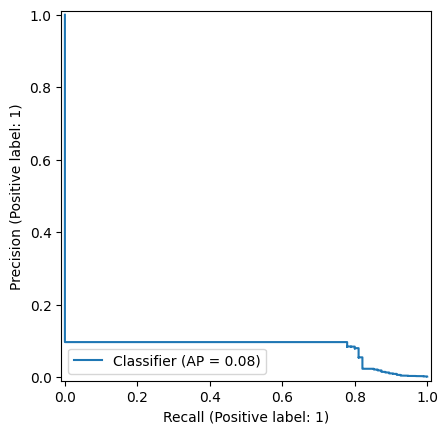

In [26]:
gb= GaussianNB(var_smoothing = 1e-9).fit(X_train,y_train)
y_pred_gb= gb.predict(X_test)
y_pred_gb_proba = gb.predict_proba(X_test)[:,1]

print(classification_report(y_test,y_pred_gb))
cm = confusion_matrix(y_pred=y_pred_gb,y_true= y_test)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=[0,1],
            yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(f"ROC-AUC score for Gaussian NB : {roc_auc_score(y_test,y_pred_gb_proba)}")
print(f"PR-AUC score for Gaussian NB : {average_precision_score(y_test,y_pred_gb_proba)}")
RocCurveDisplay.from_predictions(y_test,y_pred_gb_proba)
PrecisionRecallDisplay.from_predictions(y_test,y_pred_gb_proba)
plt.show()

For Minority Class -> Positive Class
good recall ->81% -> Model is able to understand and Find positive classes
out off total positive classes
Bad Precision -> 5% -> Model gives lots of false alarm, a normal activity being
labeled as fraud can cause losses at this amount

The model has surprisingly high recall, probably due to introduction of synthetic samples in a concentrated feature space but it has only 5% Precision meaning the model has a high tendency to classify legitimate transactions as Fraud which can be dangerous and hence cannot be used

The Model has great number of TN which deflates the value of FPR and inflating the value of ROC-AUC, hence it is not reliable

The PR Curve shows even though the model has high recall, it significantly lacks precision which can be dangerous.

The reason: Naive Bayes works on estimation that every feature is independent of each other which may be violated here as Amount and Time are dependent(PCA features are independent)

## RandomForestClassifier

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.90      0.77      0.83        95

    accuracy                           1.00     56746
   macro avg       0.95      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



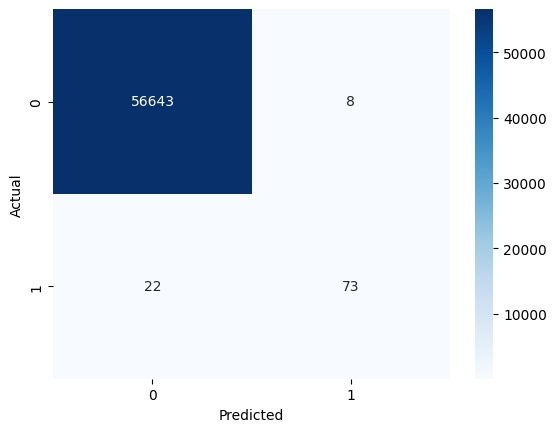

ROC-AUC score for Gaussian NB : 0.9546194660009718
PR-AUC score for Gaussian NB : 0.81464355168119


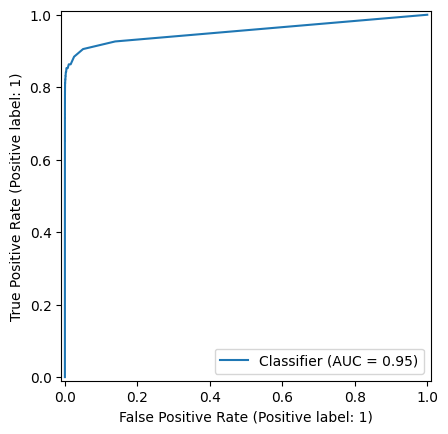

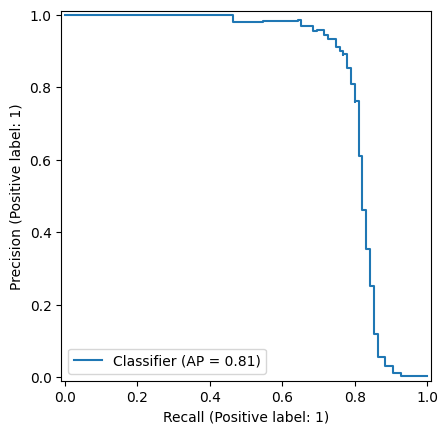

In [29]:
rf= RandomForestClassifier(n_estimators=100,
                           n_jobs=-1,
                           oob_score=True,
                           random_state=42,
                           class_weight='balanced').fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)
y_pred_rf_proba = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test,y_pred_rf))
cm2 = confusion_matrix(y_test,y_pred_rf)
sns.heatmap(cm2,annot=True,fmt='d',cmap='Blues',
            xticklabels=[0,1],
            yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(f"ROC-AUC score for Random-Forest Classifier : {roc_auc_score(y_test,y_pred_rf_proba)}")
print(f"PR-AUC score for Random-Forest Classifier : {average_precision_score(y_test,y_pred_rf_proba)}")
RocCurveDisplay.from_predictions(y_test,y_pred_rf_proba)
PrecisionRecallDisplay.from_predictions(y_test,y_pred_rf_proba)
plt.show()

Random-Forest is more stable across every parameter,

it has 100% accuracy, which can be misleading, Test set has comparatively way less samples belonging to Fraud class (only 0.17%), even if the model classified all the fraud samples incorrectly,the 99.83% accuracy would round up to 100% hence accuracy cannot be considdered a proper metric, hence we look for Precision, Recall and F1-Score.

On those parameters as well Random-Forest performs way better than Naive Bayes for Precision and Naive Bayes has a bit better Recall Than Random-Forest.

Random Forest surpasses Naive bayes for both ROC and PR Curve having higher Area under Curve for both the parameters.

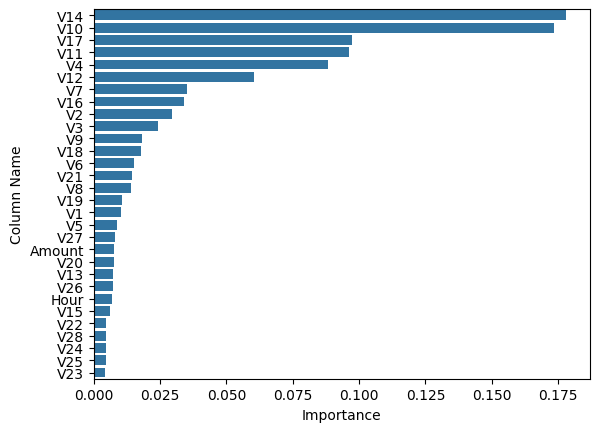

In [36]:
feature_df = pd.DataFrame({"Column Name": X.columns.to_list(),
                           "Importance":rf.feature_importances_}).sort_values(by="Importance",ascending=False)
sns.barplot(data=feature_df,x="Importance",y="Column Name")
plt.show()

# Model Comparison
|Feature|GaussianNB|Random-Forest|
|---|---|---|
|Accuracy|98%|100%|
|Precision|5%|90%|
|Recall|81%|77%|
|F1-Score|10%|83%|
|ROC-AUC|94%|95%|
|AUPRC|8%|81%|

**Note:** All the metrics are mesured as per Positive(Fraud) class


Among these two classifiers, Random Forest beats Naive Bayes at almost
every metric.

AUPRC is the most significant evidence — Random Forest (0.81) vs Naive
Bayes (0.08) — on a dataset this imbalanced, AUPRC reveals the true
discrimination ability of each model far more honestly than ROC-AUC.

**Recommendation:** Random Forest is the production choice. A missed
fraud case (False Negative) costs the bank the full transaction amount
and damages customer trust. A false alarm (False Positive) only blocks
one transaction temporarily — a far smaller cost. Since minimising False
Negatives is the priority, Recall is the key metric — and while both
models have similar Recall (81% vs 77%), Random Forest's Precision of
90% vs NB's 5% means RF achieves this with dramatically fewer false
alarms, making it operationally viable.